In [52]:
import sys
print(sys.executable)

d:\git\01_mdls_ds8_open\08_dl\260306_df_practice\.venv\Scripts\python.exe


# 263036/dl/04_텐서 표현과 연산

## 텐서(Tensor)
- 텐서(Tensor)는 데이터를 담기위한 컨테이너(container)로서 다차원 배열 또는 리스트 형태와 유사합니다. 
- 일반적으로 수치형 데이터를 저장하고, 동적 크기를 가집니다. 
- 텐서플로우(TensorFlow)는 데이터 표현과 다양한 수학식을 계산하기 위한 기본 구조로 텐서를 사용해서 표현합니다.

- 텐서는 형상이 존재하며 데이터의 표현에 따라서 사용합니다. 사용되는 용어는 다음과 같습니다.
    - Rank: 축(차원)의 개수
    - Shape: 형상(각 축의 요소의 개수)
    - Type: 데이터 타입

- `tf.constant()`를 사용하면 상수(constant) 텐서를 만들 수 있고, 
- 만든 텐서에 `tf.rank()`를 적용하면 축의 개수를 알 수 있습니다.

In [53]:
import tensorflow as tf

# 0D Tensor(Scalar)
# 0차원 텐서는 하나의 숫자를 담고 있는 텐서(tensor)입니다. 
# 스칼라(scalar)라고도 부르며, 축과 형상이 없습니다.

t0 = tf.constant(1) 
print(t0)
print(tf.rank(t0)) # 축의 개수를 반환합니다.


# 1D Tensor(Vector)
# 1차원 텐서는 값들을 저장한 리스트와 유사한 텐서입니다. 
# 벡터(vector)라고도 부르며, 하나의 축이 존재합니다.
print("="*60)
t1 = tf.constant([1, 2, 3]) 
print(t1)
print(tf.rank(t1))


# 2D Tensor(Matrix)
# 2차원 텐서는 행렬과 같은 모양으로 두개의 축이 존재합니다. 
# 일반적인 수치, 통계 데이터셋이 여기에 해당됩니다. 
# 주로 샘플(samples)과 특성(features)을 가진 구조로 사용됩니다. 
print("="*60)
t2 = tf.constant([[1, 2, 3],
                  [4, 5, 6],
                  [7, 8, 9]])
print(t2)
print(tf.rank(t2))



# 3D Tensor
# 3차원 텐서는 큐브(cube)와 같은 모양으로 세개의 축이 존재하며, 
# 일반적으로 데이터가 연속된 시퀀스 데이터나 시간 축이 포함된 시계열 데이터에 해당합니다. 
# 주로 샘플(samples), 타임스텝(timesteps), 특성(features)을 가진 구조로 사용됩니다. 
# 3차원 텐서를 이용하는 데이터로는 주식 가격 데이터셋, 시간에 따른 질병 발병 데이터 등이 존재합니다.

print("="*60)
t3 = tf.constant([
    [[1, 2, 3],
     [4, 5, 6],
     [7, 8, 9]],

    [[10, 11, 12],
     [13, 14, 15],
     [16, 17, 18]],

    [[19, 20, 21],
     [22, 23, 24],
     [25, 26, 27]]
])

print(t3)
print(tf.rank(t3)) 


# 4D/5D Tensor
# 주로 이미지 데이터 및 비디오 데이터 


tf.Tensor(1, shape=(), dtype=int32)
tf.Tensor(0, shape=(), dtype=int32)
tf.Tensor([1 2 3], shape=(3,), dtype=int32)
tf.Tensor(1, shape=(), dtype=int32)
tf.Tensor(
[[1 2 3]
 [4 5 6]
 [7 8 9]], shape=(3, 3), dtype=int32)
tf.Tensor(2, shape=(), dtype=int32)
tf.Tensor(
[[[ 1  2  3]
  [ 4  5  6]
  [ 7  8  9]]

 [[10 11 12]
  [13 14 15]
  [16 17 18]]

 [[19 20 21]
  [22 23 24]
  [25 26 27]]], shape=(3, 3, 3), dtype=int32)
tf.Tensor(3, shape=(), dtype=int32)


## 텐서 타입 및 변환

### 텐서의 타입 

| Data type     | TF type       | Description                         |
| ------------- | ------------- | ----------------------------------- |
| DT_FLOAT      | tf.float32    | 32비트 부동 소수                          |
| DT_DOUBLE     | tf.float64    | 64비트 부동 소수                          |
| DT_INT8       | tf.int8       | 8비트 부호 있는 정수                        |
| DT_INT16      | tf.int16      | 16비트 부호 있는 정수                       |
| DT_INT32      | tf.int32      | 32비트 부호 있는 정수                       |
| DT_INT64      | tf.int64      | 64비트 부호 있는 정수                       |
| DT_UINT8      | tf.uint8      | 8비트 부호 없는 정수                        |
| DT_STRING     | tf.string     | 가변 길이 바이트 배열 (Tensor의 각 원소는 바이트 배열) |
| DT_BOOL       | tf.bool       | 불리언(Boolean)                        |
| DT_COMPLEX64  | tf.complex64  | 2개의 32비트 부동 소수(실수부 + 허수부)로 구성된 복소수  |
| DT_COMPLEX128 | tf.complex128 | 2개의 64비트 부동 소수(실수부 + 허수부)로 구성된 복소수  |
| DT_QINT8      | tf.qint8      | 8비트 부호 있는 정수 (quantized 연산용)        |
| DT_QINT32     | tf.qint32     | 32비트 부호 있는 정수 (quantized 연산용)       |
| DT_QUINT8     | tf.quint8     | 8비트 부호 없는 정수 (quantized 연산용)        |

### 텐서의 생성

In [54]:
# 상수 값 2인 텐서를 생성해 봅시다. 기본적으로 정수형 `int32` 타입을 가지는 것을 알 수 있습니다.
# 상수 값 2.0으로 지정하면, 실수형 `float32`인 텐서를 생성합니다.
# 문자열을 값으로 가지는 텐서를 생성할 수도 있으며, 타입은 `string`이 됩니다.
# 지정한 상수 값의 타입을 보고 자동으로 텐서 타입이 정해지는 것 외에도 필요한 텐서의 타입을 지정하여 생성할 수 있습니다. 
# 여기서는 `tf.float16`으로 16비트 실수형으로 타입을 지정하였습니다.
i = tf.constant(2)
print(i)

f = tf.constant(2.)
print(f)

s = tf.constant('Suan')
print(s)

f16 = tf.constant(2., dtype=tf.float16)
print(f16)

tf.Tensor(2, shape=(), dtype=int32)
tf.Tensor(2.0, shape=(), dtype=float32)
tf.Tensor(b'Suan', shape=(), dtype=string)
tf.Tensor(2.0, shape=(), dtype=float16)


In [55]:
# 그 밖에도 8비트의 정수형인 `tf.int8`을 지정하여 텐서를 생성할 수 있습니다.
int8 = tf.constant(10, dtype=tf.int8 )
print(int8)

tf.Tensor(10, shape=(), dtype=int8)


### 텐서 변환

| 함수             | 설명                                                             |
| -------------- | -------------------------------------------------------------- |
| tf.shape       | 텐서의 구조(차원 크기)를 반환합니다. 예: (batch_size, height, width, channels) |
| tf.size        | 텐서의 전체 원소 개수를 반환합니다.                                           |
| tf.rank        | 텐서의 랭크(rank, 즉 차원 수)를 반환합니다.                                   |
| tf.reshape     | 원소 수는 유지한 채 텐서의 구조(shape)를 변경합니다.                              |
| tf.squeeze     | 크기가 1인 차원을 제거합니다 (예: (1, 3, 1) → (3,)).                        |
| tf.expand_dims | 지정한 위치에 새로운 차원을 추가합니다 (예: (3,) → (1, 3)).                      |
| tf.slice       | 텐서의 일부 구간을 추출합니다 (인덱스 범위 지정).                                  |
| tf.split       | 한 축(axis)을 기준으로 텐서를 여러 개로 분할합니다.                               |
| tf.tile        | 텐서를 지정된 횟수만큼 복제하여 확장합니다.                                       |
| tf.concat      | 지정한 축(axis)을 기준으로 여러 텐서를 이어 붙입니다.                              |
| tf.reverse     | 지정한 축을 기준으로 텐서를 뒤집습니다.                                         |
| tf.transpose   | 텐서의 축(axis) 순서를 바꿔 전치(transpose)합니다.                           |
| tf.gather      | 주어진 인덱스 배열에 따라 텐서의 원소를 모아 새 텐서를 만듭니다.                          |

In [56]:
# 텐서 타입 변환
# 텐서의 타입을 변환하고자 할 때는 tf.cast를 사용합니다. 
# 여기서는 16비트 실수 tf.float16을 32비트 실수 tf.float32로 변환하였습니다.
f16 = tf.constant(2., dtype=tf.float16)
f32 = tf.cast(f16, tf.float32)
print(f32)

# 다음 예제에서는  tf.int8을 3 tf.int32로 변환하고자 합니다. 
# 예:8비트 정수형 텐서
i8 = tf.constant(10, dtype=tf.int8)
print(i8)
# 32비트 정수형으로 변환
i32 = tf.cast(i8, tf.int32)
print(i32)         # tf.Tensor(10, shape=(), dtype=int32)

tf.Tensor(2.0, shape=(), dtype=float32)
tf.Tensor(10, shape=(), dtype=int8)
tf.Tensor(10, shape=(), dtype=int32)


In [57]:
# 텐서 형상 변환
# 텐서의 형상을 변환하는 것은 `tf.reshape` 함수를 통해 가능합니다. 
# 이 함수는 텐서의 원소는 그대로 유지하면서 텐서의 구조를 바꿉니다.
x = tf.constant([[1], [2], [3]]) # 3행 1열짜리 2차원 텐서
print(x)
print(x.shape)

y = tf.reshape(x, [1, 3]) # 1행 3열짜리 2차원 텐서
print(y)
print(y.shape)

tf.Tensor(
[[1]
 [2]
 [3]], shape=(3, 1), dtype=int32)
(3, 1)
tf.Tensor([[1 2 3]], shape=(1, 3), dtype=int32)
(1, 3)


In [58]:
# 텐서 전치
# 텐서를 전치하여 형상을 바꾸는 역할로 `tf.transpose` 함수를 사용할 수 있습니다.
print(y)
print(tf.transpose(y))
print(y.shape)


tf.Tensor([[1 2 3]], shape=(1, 3), dtype=int32)
tf.Tensor(
[[1]
 [2]
 [3]], shape=(3, 1), dtype=int32)
(1, 3)


In [59]:
# 차원 압축
# 텐서에서 크기가 1인 차원을 제거하는 tf.squeeze 함수를 이용해 형상을 변경합니다.
print(x) 
print(tf.squeeze(x))

# 원본 
# shape: (3, 1) → 3행 1열짜리 2차원 텐서

# 결과 
# shape: (3,) → 1차원 벡터
# 길이가 3인 한 축만 남음
# (3, 1) 중에서 크기가 1인 축(뒤의 1) 만 제거됨
# 그래서 (3, 1) → (3,)
# 값의 순서 1, 2, 3은 그대로이고, 열 1개라는 껍데기 축 만 없어진 것

# 같은 패턴으로, 예를 들어 (1, 3, 1)이면 크기 1인 앞/뒤 축이 다 빠져서 (3,)가 되고, 
# (1, 3, 2)이면 크기 1인 앞 축만 빠져서 (3, 2)가 됩니다.


tf.Tensor(
[[1]
 [2]
 [3]], shape=(3, 1), dtype=int32)
tf.Tensor([1 2 3], shape=(3,), dtype=int32)


In [60]:
# 차원 추가
# 텐서의 차원을 추가하는 tf.expand_dims 함수를 이용해 형상을 변경합니다. 
# 여기서 axis는 차원을 확장할 텐서의 축을 지정해주는 역할을 합니다.
print(y)
print(tf.expand_dims(y, axis=0)) # axis=0 : 맨 앞에 새 차원을 하나 추가
print(tf.expand_dims(y, axis=1)) # axis=1 : 두 번째 위치(인덱스 1)에 새 차원을 추가
print(tf.expand_dims(y, axis=2)) # axis=2 : 원래 1차원 텐서에는 유효하지 않은 축 인덱스

# axis는 새 차원을 어느 위치에 끼워 넣을지를 결정하는 인덱스
# 각 차원(축)에 번호를 매겨 놓고, 그 번호를 기준으로 어디에 새 차원을 넣을지/지울지를 지정
"""
tf.expand_dims(y, axis=0)
→ “0번 축 앞에 새 축 하나 끼워 넣는다” → (1, 3)

tf.expand_dims(y, axis=1)
→ “0번 축 뒤에 새 축 하나 끼워 넣는다” → (3, 1)
"""

tf.Tensor([[1 2 3]], shape=(1, 3), dtype=int32)
tf.Tensor([[[1 2 3]]], shape=(1, 1, 3), dtype=int32)
tf.Tensor([[[1 2 3]]], shape=(1, 1, 3), dtype=int32)
tf.Tensor(
[[[1]
  [2]
  [3]]], shape=(1, 3, 1), dtype=int32)


'\ntf.expand_dims(y, axis=0)\n→ “0번 축 앞에 새 축 하나 끼워 넣는다” → (1, 3)\n\ntf.expand_dims(y, axis=1)\n→ “0번 축 뒤에 새 축 하나 끼워 넣는다” → (3, 1)\n'

In [61]:
# 텐서 분리
# tf.split 함수를 이용하여 텐서의 지정한 차원을 기준으로 
# 여러 개의 텐서로 구분합니다
# 예제에서는 텐서 x를 3개로 분리한 것을 알 수 있습니다.
print(x)  # → 3행 1열짜리 2차원 텐서
print(tf.split(x, 3))


# 0번 축(axis=0, 행 방향)을 따라 -> axis 따로 명시 안하면  axis=0 이 디폴트 
# 길이 3을 “3등분”해서
# (1행 1열) 텐서 3개로 나눈 것

tf.Tensor(
[[1]
 [2]
 [3]], shape=(3, 1), dtype=int32)
[<tf.Tensor: shape=(1, 1), dtype=int32, numpy=array([[1]])>, <tf.Tensor: shape=(1, 1), dtype=int32, numpy=array([[2]])>, <tf.Tensor: shape=(1, 1), dtype=int32, numpy=array([[3]])>]


In [62]:
# 텐서 연결
# tf.concat 함수는 지정한 축 axis를 기준으로 텐서들을 이어붙입니다.

print(x)
print(tf.concat([x, x], axis=0))
print(tf.concat([x, x], axis=1))

"""
shape (행, 열)인 2D 텐서에서:
    axis=0 → 행 방향(위→아래)으로 처리
        예: tf.split(x, 3, axis=0) → 행을 기준으로 3조각
    axis=1 → 열 방향(왼→오른쪽)으로 처리
        예: tf.split(x, 1, axis=1) → 열을 기준으로 나누기

더 일반화하면:
축 번호는 shape의 인덱스와 같음
axis=0 → shape의 첫 번째 값 방향
axis=1 → shape의 두 번째 값 방향
axis=2 → shape의 세 번째 값(깊이, 채널 등) 방향 …
"""

tf.Tensor(
[[1]
 [2]
 [3]], shape=(3, 1), dtype=int32)
tf.Tensor(
[[1]
 [2]
 [3]
 [1]
 [2]
 [3]], shape=(6, 1), dtype=int32)
tf.Tensor(
[[1 1]
 [2 2]
 [3 3]], shape=(3, 2), dtype=int32)


'\nshape (행, 열)인 2D 텐서에서:\n    axis=0 → 행 방향(위→아래)으로 처리\n        예: tf.split(x, 3, axis=0) → 행을 기준으로 3조각\n    axis=1 → 열 방향(왼→오른쪽)으로 처리\n        예: tf.split(x, 1, axis=1) → 열을 기준으로 나누기\n\n더 일반화하면:\n축 번호는 shape의 인덱스와 같음\naxis=0 → shape의 첫 번째 값 방향\naxis=1 → shape의 두 번째 값 방향\naxis=2 → shape의 세 번째 값(깊이, 채널 등) 방향 …\n'

## 텐서 연산

### 0차원 텐서의 연산

In [63]:
print(tf.constant(2) + tf.constant(2))
print(tf.constant(2) - tf.constant(2))
print(tf.add(tf.constant(2), tf.constant(2)))
print(tf.subtract(tf.constant(2), tf.constant(2)))

print(tf.constant(2) * tf.constant(2))
print(tf.constant(2) / tf.constant(2))
print(tf.multiply(tf.constant(2), tf.constant(2)))
print(tf.divide(tf.constant(2), tf.constant(2)))

#print(tf.constant(2) + tf.constant(2.2))

print(tf.cast(tf.constant(2), tf.float32) + tf.constant(2.2))

tf.Tensor(4, shape=(), dtype=int32)
tf.Tensor(0, shape=(), dtype=int32)
tf.Tensor(4, shape=(), dtype=int32)
tf.Tensor(0, shape=(), dtype=int32)
tf.Tensor(4, shape=(), dtype=int32)
tf.Tensor(1.0, shape=(), dtype=float64)
tf.Tensor(4, shape=(), dtype=int32)
tf.Tensor(1.0, shape=(), dtype=float64)
tf.Tensor(4.2, shape=(), dtype=float32)


### 1차원 이상의 텐서 연산

In [64]:
# 1차원 텐서 2개를 만들어 봅시다.
# 생성된 2개의 텐서에 사칙연산을 해봅시다.

# 1) 1차원 텐서 2개 만들기
a = tf.constant([1, 2, 3], dtype=tf.int32)
b = tf.constant([4, 5, 6], dtype=tf.int32)

# 2) 1차원 텐서 사칙연산 (요소별 연산)
add_ab = a + b          
sub_ab = a - b         
mul_ab = a * b        
div_ab = a / b   

print(add_ab)          
print(sub_ab)         
print(mul_ab)        
print(div_ab)   

tf.Tensor([5 7 9], shape=(3,), dtype=int32)
tf.Tensor([-3 -3 -3], shape=(3,), dtype=int32)
tf.Tensor([ 4 10 18], shape=(3,), dtype=int32)
tf.Tensor([0.25 0.4  0.5 ], shape=(3,), dtype=float64)


In [65]:
# 2차원 텐서를 생성한 후 연산을 해 봅시다.
# 텐서를 계산하기 위한 여러 연산자들을 제공하고 있으며, 
# +, -, *, / 연산자는 요소별(element-wise) 연산을 수행하고, 
# @ 연산자의 경우에는 행렬 곱 연산을 수행합니다.

m1 = tf.constant([[1, 2],
                  [3, 4]], dtype=tf.float32)

m2 = tf.constant([[5, 6],
                  [7, 8]], dtype=tf.float32)

m_add = m1 + m2         
m_sub = m1 - m2         
m_mul = m1 * m2      
m_div = m1 / m2        
print("m1 + m2 =\n", m_add)
print("m1 - m2 =\n", m_sub)
print("m1 * m2 =\n", m_mul)
print("m1 / m2 =\n", m_div)

# 행렬 곱(@, matmul)
m_matmul = m1 @ m2      # 또는 tf.matmul(m1, m2)
print("m1 @ m2 =\n", m_matmul)

"""
그 밖에도 유용한 여러 함수들이 존재합니다.

- `reduce_max()`: 텐서 값 중에서 최대값을 계산합니다.
- `argmax()`: 최대값의 위치를 반환합니다. 
- `nn.softmax()`: 텐서의 값을 0과 1 사이의 값으로 보여줍니다.
"""

m1 + m2 =
 tf.Tensor(
[[ 6.  8.]
 [10. 12.]], shape=(2, 2), dtype=float32)
m1 - m2 =
 tf.Tensor(
[[-4. -4.]
 [-4. -4.]], shape=(2, 2), dtype=float32)
m1 * m2 =
 tf.Tensor(
[[ 5. 12.]
 [21. 32.]], shape=(2, 2), dtype=float32)
m1 / m2 =
 tf.Tensor(
[[0.2        0.33333334]
 [0.42857143 0.5       ]], shape=(2, 2), dtype=float32)
m1 @ m2 =
 tf.Tensor(
[[19. 22.]
 [43. 50.]], shape=(2, 2), dtype=float32)


'\n그 밖에도 유용한 여러 함수들이 존재합니다.\n\n- `reduce_max()`: 텐서 값 중에서 최대값을 계산합니다.\n- `argmax()`: 최대값의 위치를 반환합니다. \n- `nn.softmax()`: 텐서의 값을 0과 1 사이의 값으로 보여줍니다.\n'

## 4-5. 마무리하며

### 종합문제 

In [66]:
a = tf.constant([1, 2, 3, 4, 5, 6, 7, 8]) 
b = tf.constant([[1., 2., 3., 4., 5., 6., 7., 8.]])


# Q. 위에 있는 2개의 텐서를 행렬곱연산이 가능하도록 3차원 텐서로 변환해주세요.

# a 를 (batch=1, rows=2, cols=4) 모양의 3D 텐서로
a_f = tf.cast(a, tf.float32)      # shape=(8,)
a_3d = tf.reshape(a_f, (1, 2, 4))  # shape=(1, 2, 4)

# b 는 원래 (1, 8) → 먼저 2D 행렬 (4, 2) 로 만든 뒤, 3D 로 확장
b_2d = tf.reshape(b, (4, 2))       # shape=(4, 2)
b_3d = tf.reshape(b_2d, (1, 4, 2)) # shape=(1, 4, 2)


print(a_3d @ b_3d )

tf.Tensor(
[[[ 50.  60.]
  [114. 140.]]], shape=(1, 2, 2), dtype=float32)


# 260306/dl/05_딥러닝 구조와 모델

## 딥러닝 구조와 레이어(Layer)

### Input 객체
- 딥러닝 모델의 입력을 정의할 때 사용하는 `Input` 객체는 입력 데이터의 모양인 `shape`와 예상되는 데이터 유형인 `dtype` 등을 포함하고 있습니다.
- `Input` 객체는 배치 크기를 `batch_size`로 지정할 수 있고, `name`을 통해서 이름을 지정할 수도 있습니다.

In [67]:
###

In [68]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [69]:
keras.Input(shape=(8,), dtype=tf.int32)
keras.Input(shape=(28, 28), dtype=tf.float32)
keras.Input(shape=(28, 28), dtype=tf.float32, batch_size=16)
keras.Input(shape=(28, 28), dtype=tf.float32, batch_size=16, name='input')

<KerasTensor shape=(16, 28, 28), dtype=float32, sparse=False, ragged=False, name=input>

### Dense 레이어
- Dense 레이어는 완전연결계층(Fully-Connected Layer)으로 노드수(유닛수)를 지정하면 생성됩니다. 
- Dense 레이어에 대한 자세한 내용은 다음 링크를 참조하면 됩니다.  [https://keras.io/api/layers/core_layers/dense/](https://keras.io/api/layers/core_layers/dense/)

In [70]:
layers.Dense(10)
layers.Dense(10, name='layer1') # 레이어에 name을 통해 이름을 지정하여 레이어간의 구분이 가능합니다.
layers.Dense(10, activation='softmax') # 레이어에서 사용할 활성화 함수(activation)를 지정하여 생성하는 것이 가능합니다.
layers.Dense(10, activation='relu', name='Dense Layer') # 레이어에 유닛수와 활성화 함수 그리고 이름까지 지정하여 사용하는 것도 가능합니다.


# 랜덤으로 값을 만들고, 생성한 레이어에 그 값을 입력으로 사용한 뒤에 
# 레이어 가중치 값과 결과 값을 확인해 봅시다.
inputs = tf.random.uniform(shape=(5, 2))
print(inputs)

print("\n","="*60)
layer = layers.Dense(10, activation='relu')
outputs = layer(inputs)
print("\n",layer.weights)
print("\n",layer.bias)
print("\n",outputs)

tf.Tensor(
[[0.9109067  0.08304036]
 [0.27544188 0.08788109]
 [0.37446666 0.12448573]
 [0.06622016 0.4478104 ]
 [0.8953279  0.7328299 ]], shape=(5, 2), dtype=float32)


 [<Variable path=dense_52/kernel, shape=(2, 10), dtype=float32, value=[[ 0.6831613  -0.29552478 -0.24876437  0.05240941  0.6952575  -0.27824017
   0.60966104  0.6600049   0.04475558 -0.2866525 ]
 [-0.4081096  -0.23756796 -0.1253717  -0.22097355  0.3159048   0.404707
   0.5473234  -0.6713711   0.19012815 -0.6493403 ]]>, <Variable path=dense_52/bias, shape=(10,), dtype=float32, value=[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]>]

 <Variable path=dense_52/bias, shape=(10,), dtype=float32, value=[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]>

 tf.Tensor(
[[0.5884066  0.         0.         0.02939036 0.6595475  0.
  0.6007942  0.545452   0.05655646 0.        ]
 [0.15230612 0.         0.         0.         0.21926509 0.
  0.21602558 0.12279218 0.02903623 0.        ]
 [0.20501731 0.         0.         0.         0.29967636 0.
  0.2964317  0.16357371 0.

### Activation 레이어
- 활성화 함수는 이전 레이어의 결과값을 변환하여 다른 레이어로 전달하는 역할
- 딥러닝에서는 선형 활성화 함수를 사용하면 다층 구조를 사용하는 의미가 없기 때문에 모델 표현력을 위해서 비선형 활성화 함수를 사용
-  Dense 레이어에서 미리 활성화 함수를 지정할 수도 있지만, 필요에 따라 별도의 Activation 레이어를 만들어줄 수 있습니다.
-  Keras에서 제공하는 활성화 함수(activation function)의 종류:  [https://keras.io/api/layers/activations/](https://keras.io/api/layers/activations/)

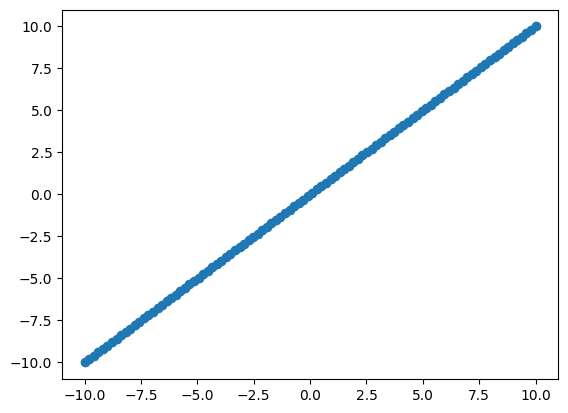

In [71]:
# Activation 레이어가 어떤식으로 동작하는지 살펴보기 위해서 
# -10부터 10 사이의 수 가운데 100개의 값을 입력 데이터로 사용해 봅시다.

import numpy as np
import matplotlib.pyplot as plt

input = np.linspace(-10, 10, 100)
x = np.linspace(-10, 10, 100)
plt.scatter(x, input)
plt.show()

#### 시그모이드 함수

- 활성화 함수 중에서도 오래전부터 사용되던 시그모이드(sigmoid) 함수는 다음과 같이 표현됩니다.

$$
\sigma(x) = \frac{1}{1 + e^{-x}}
$$

- 시그모이드 함수는 주로 확률 예측 모델에 자주 사용되며, **출력값이 0과 1 사이**로 나타납니다. 
- 그러다보니 **0과 1 사이에서 포화(saturate)**되는 문제가 있습니다. 즉, 입력값이 작아도 출력값이 0 이하가 될 수 없고, 
- 커져도 1 이상이 될 수 없기 때문에 훈련 시간이 오래걸리고, 그래디언트(gradient)가 0에 가까워져서 
- 가중치 업데이트가 발생하지 않게 됩니다.

> **시그모이드 함수는 비선형 함수이지만 0과 1 사이에서는 선형 함수입니다.**

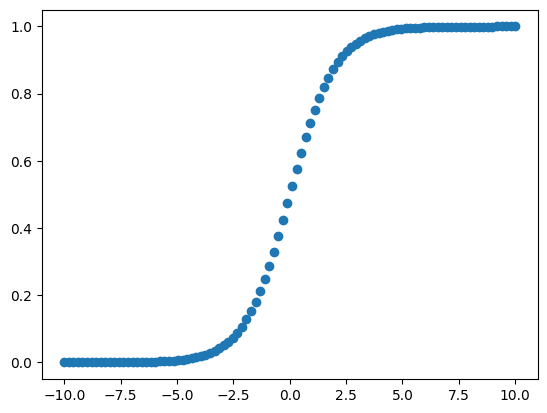

In [72]:
layer = layers.Activation('sigmoid')
output = layer(input)

plt.scatter(x, output)
plt.show()

#### 하이퍼볼릭 탄젠트 함수

- 하이퍼볼릭 탄젠트(tanh, Hyperbolic tangent) 함수는 다음과 같이 표현됩니다.

$$
\tanh(x) = \frac{e^{x} - e^{-x}}{e^{x} + e^{-x}}
$$

$$
\tanh(x) = 2\sigma(2x) - 1
$$

- 하이퍼볼릭 탄젠트 함수는 0을 중심으로 -1과 1 사이의 값이 나타납니다. 
- 일반적으로 시그모이드 함수보다는 빨리 훈련되지만, **여전히 -1과 1 사이에서 포화**되는 문제가 있습니다.

> **하이퍼볼릭 탄젠트 함수는 비선형 함수이지만 0과 1 사이에서는 선형 함수입니다.**

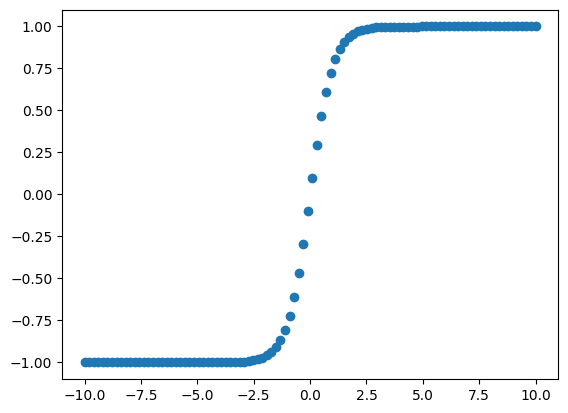

In [73]:
layer = layers.Activation('tanh')
output = layer(input)

plt.scatter(x, output)
plt.show()

#### ReLU 함수

- 최근에 가장 많이 사용하는 활성화 함수인 ReLU(Rectified Linear Unit)는 다음과 같이 표현됩니다.

$$
\mathrm{ReLU}(x) = \max(0, x)
$$

- ReLU 함수의 출력값은 0부터 무한대까지의 범위의 값을 가지므로 하이퍼볼릭 탄젠트 함수보다 몇 배는 더 빠르게 훈련됩니다. 
- 다만 ReLU 함수 출력값이 0이 중심이 아니고, 학습률(learning rate)이 크면 ReLU를 사용한 노드에서 출력이 0으로만 나온다는 문제가 있습니다.

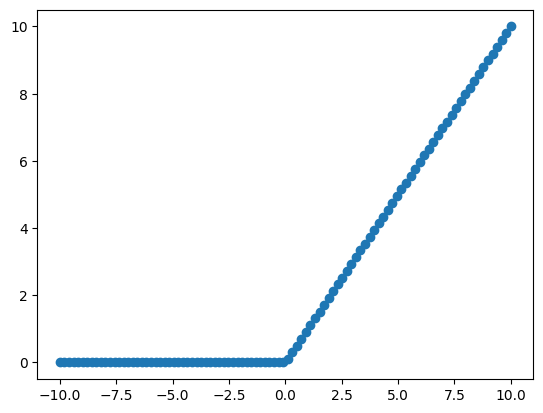

In [74]:
layer = layers.Activation('relu')
output = layer(input)

plt.scatter(x, output)
plt.show()

####  Leaky ReLU 함수

- Leaky ReLU 함수는 ReLU 함수의 문제점, 즉 노드 출력을 0으로만 하던 문제를 해결하였으며 다음과 같이 표현됩니다.

$$
\mathrm{LeakyReLU}(x) =
\begin{cases}
\alpha x, & x < 0 \\
x, & x \ge 0
\end{cases}
$$

- Leaky ReLU 함수는 노드 출력을 0이 아닌 아주 작은 음수값으로 출력하게 만들어 해결하였습니다.

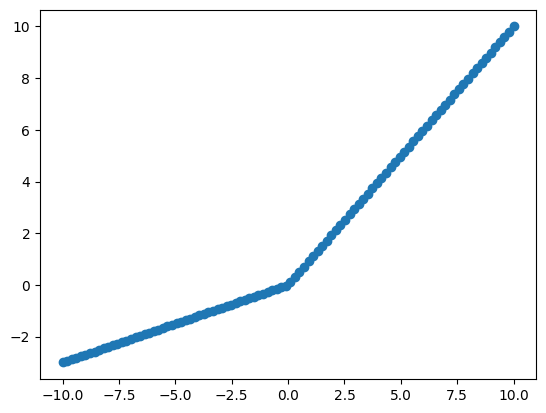

In [75]:
layer = layers.LeakyReLU()
output = layer(input)

plt.scatter(x, output)
plt.show()

#### ELU 함수

- ELU(Exponential Linear Unit) 함수는 ReLU가 중심점이 0이 아니고, 노드 출력을 0으로만 하던 문제를 해결한 활성화 함수이며, 다음과 같이 표현됩니다.

$$
\mathrm{ELU}(x) =
\begin{cases}
x, & x \ge 0 \\
\alpha (e^{x} - 1), & x < 0
\end{cases}
$$

- ELU 함수는 0 이하에서는 exponential 연산이 수행되므로 계산 비용이 높아지는 단점이 있습니다.

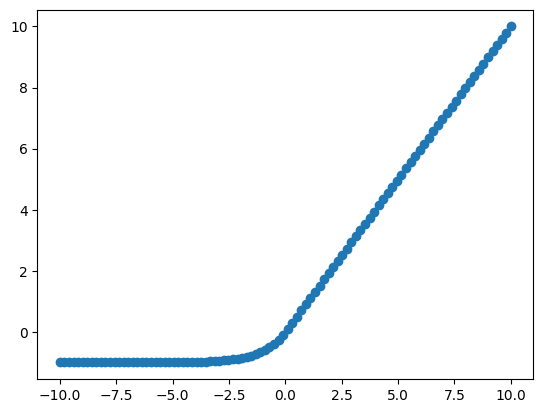

In [76]:
layer = layers.ELU()
output = layer(input)

plt.scatter(x, output)
plt.show()

### Flatten 레이어
- Flatten 레이어는 배치 크기(또는 데이터 크기)를 제외하고 데이터를 1차원 형태로 평평하게 변환합니다.

In [77]:
inputs = keras.Input(shape=(28, 28, 1))
layer = layers.Flatten(input_shape=(28, 28, 1))(inputs)
print(layer.shape)


inputs = keras.Input(shape=(224, 224, 1))
layer = layers.Flatten()(inputs)
print(layer.shape)

(None, 784)
(None, 50176)


d:\git\01_mdls_ds8_open\08_dl\260306_df_practice\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## 5-3. 딥러닝 모델
딥러닝 모델을 구성하는 방법은 
1.  Sequential() 함수를 이용한 Sequential API 방법과 
2. Functional API를 이용하는 방법, 그리고 
3. Subclassing API를 이용하는 방법이 있습니다.

### Sequential API
- Sequential API를 이용하는 방법은 모델이 순차적인 구조로 진행할 때 사용하는 간단한 방법입니다. 
- 다만 이 방법은 다중 입력 및 출력이 존재하는 등의 복잡한 모델을 구성할 수 없습니다.
- Sequential API를 이용한 방법 중 첫번째는 `Sequential` 객체 생성 후,`add()`를 이용하여 사용할 레이어들을 추가하는 방법입니다.

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_53 (Dense)                │ (None, 28, 300)        │         8,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 28, 100)        │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 28, 10)         │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,810 (155.51 KB)

 Trainable params: 39,810 (155.51 KB)

 Non-trainable params: 0 (0.00 B)

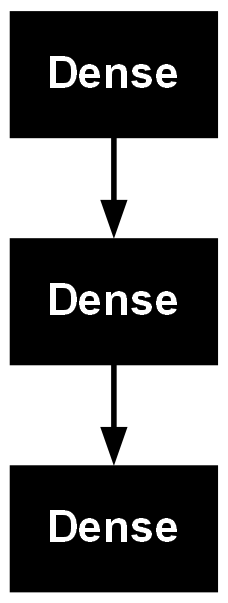

In [78]:
from tensorflow.keras import models

model = models.Sequential()
model.add(layers.Input(shape=(28, 28)))
model.add(layers.Dense(300, activation='relu'))
model.add(layers.Dense(100, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))
model.summary()

# plot_model() 함수를 통해 딥러닝 모델의 모습을 시각적으로 확인할 수 있습니다.
utils.plot_model(model)

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Dense1 (Dense)                  │ (None, 28, 300)        │         8,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense2 (Dense)                  │ (None, 28, 100)        │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 28, 10)         │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,810 (155.51 KB)

 Trainable params: 39,810 (155.51 KB)

 Non-trainable params: 0 (0.00 B)

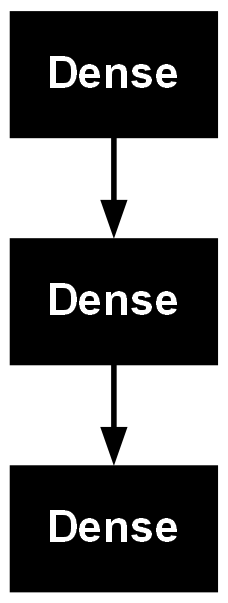

In [79]:

# 다른 방법으로는 Sequential 인자에 한번에 추가하는 방법이 있습니다.
model = models.Sequential([layers.Input(shape=(28, 28), name='Input'),
                           layers.Dense(300, activation='relu', name='Dense1'),
                           layers.Dense(100, activation='relu', name='Dense2'),
                           layers.Dense(10, activation='softmax', name='Output')])
model.summary()

utils.plot_model(model)


### Functional API
- 모델 생성에 Functional API를 이용하는 방법은 가장 권장되는 방법입니다. 
- Functional API는 딥러닝 모델을 복잡하고, 유연하게 구성하는 것이 가능하며, 다중 입출력을 다룰 수 있습니다.

Model: "functional_40"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_23 (InputLayer)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

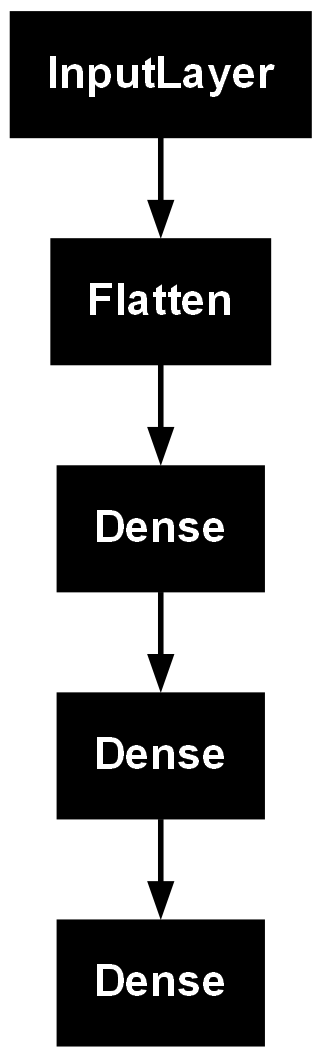

In [80]:
inputs = layers.Input(shape=(28, 28, 1))
x = layers.Flatten(input_shape=(28, 28, 1))(inputs)
x = layers.Dense(300, activation='relu')(x)
x = layers.Dense(100, activation='relu')(x)
x = layers.Dense(10, activation='softmax')(x)

model = models.Model(inputs=inputs, outputs=x)
model.summary()

utils.plot_model(model)


- Functional API를 이용하면 Input 객체를 여러 레이어에서 사용하는 것이 가능합니다. 
- 아래의 예제에서는 Concatenate()를 이용하여 
- Dense 레이어 결과와 Input을 결합하였습니다.

Model: "functional_41"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_24      │ (None, 28, 28)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_59 (Dense)    │ (None, 28, 100)   │      2,900 │ input_layer_24[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_60 (Dense)    │ (None, 28, 30)    │      3,030 │ dense_59[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 28, 58)    │          0 │ input_layer_24[0… │
│ (Concatenate)       │                   │            │ dense_60[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_61 (Dense)    │ (None, 28, 1)     │         59 │ concatenate_6[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,989 (23.39 KB)

 Trainable params: 5,989 (23.39 KB)

 Non-trainable params: 0 (0.00 B)

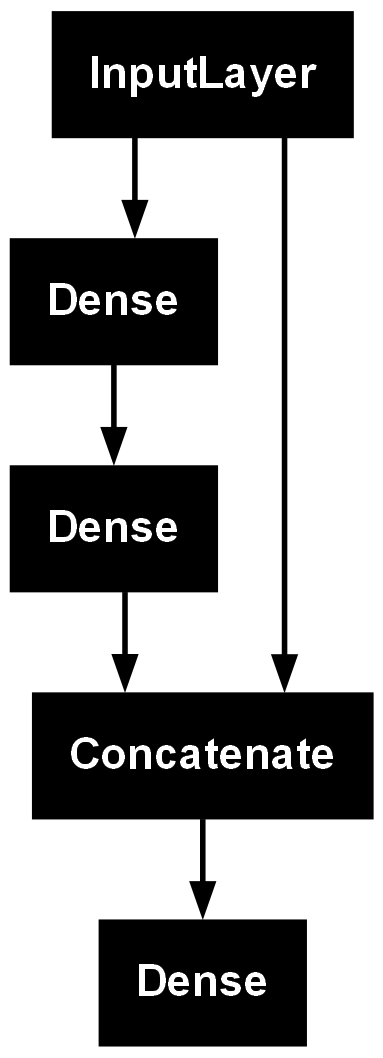

In [81]:


inputs = keras.Input(shape=(28, 28))
hidden1 = layers.Dense(100, activation='relu')(inputs)
hidden2 = layers.Dense(30, activation='relu')(hidden1)
concat = layers.Concatenate()([inputs, hidden2])
output = layers.Dense(1)(concat)

model = models.Model(inputs=[inputs], outputs=[output])
model.summary()

utils.plot_model(model)

- Functional API를 이용하면 여러 `Input` 객체를 사용하는 것도 가능합니다.
- 또한  결과를 여러개로 나눠서 사용하는 것도 가능합니다.
- 그리고  다중 입력과 다중 출력이 가능한 모델도 만들 수 있습니다.

Model: "functional_42"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input_2             │ (None, 10, 28)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_62 (Dense)    │ (None, 10, 100)   │      2,900 │ Input_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Input_1             │ (None, 10, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_63 (Dense)    │ (None, 10, 10)    │      1,010 │ dense_62[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_7       │ (None, 10, 20)    │          0 │ Input_1[0][0],    │
│ (Concatenate)       │                   │            │ dense_63[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 10, 1)     │         21 │ concatenate_7[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,931 (15.36 KB)

 Trainable params: 3,931 (15.36 KB)

 Non-trainable params: 0 (0.00 B)

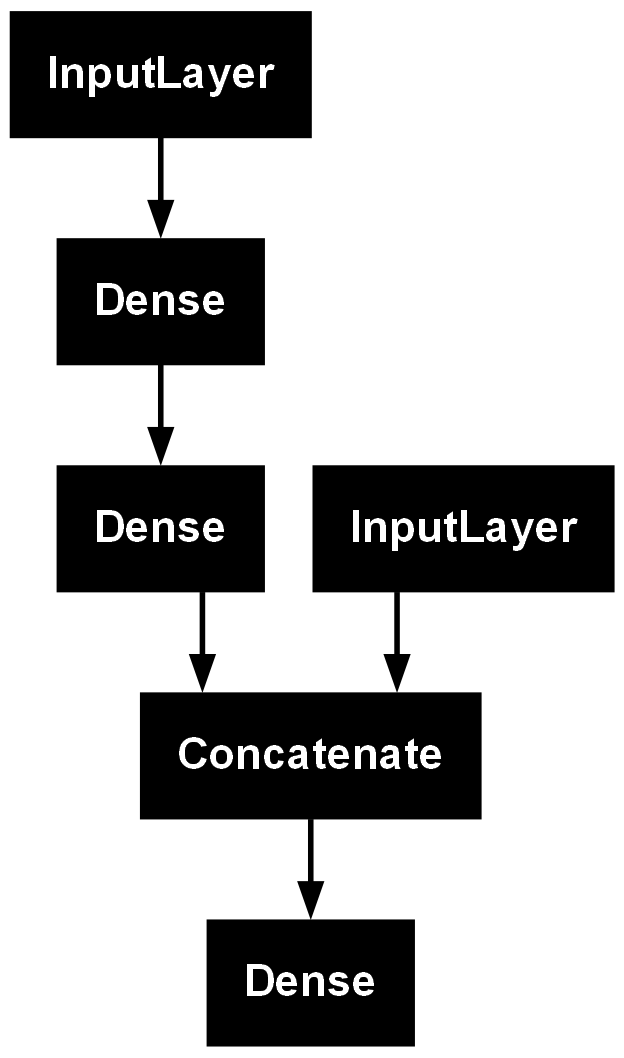

In [82]:
# 여러 input 객체 사용
input_1 = keras.Input(shape=(10, 10), name='Input_1')
input_2 = keras.Input(shape=(10, 28), name='Input_2')

hidden1 = layers.Dense(100, activation='relu')(input_2)
hidden2 = layers.Dense(10, activation='relu')(hidden1)
concat = layers.Concatenate()([input_1, hidden2])
output = layers.Dense(1, activation='sigmoid', name='output')(concat)

model = models.Model(inputs=[input_1, input_2], outputs=[output])
model.summary()

utils.plot_model(model)

Model: "functional_43"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_ (InputLayer) │ (None, 10, 10)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_64 (Dense)    │ (None, 10, 100)   │      1,100 │ input_[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_65 (Dense)    │ (None, 10, 10)    │      1,010 │ dense_64[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ main_output (Dense) │ (None, 10, 1)     │         11 │ dense_65[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sum_output (Dense)  │ (None, 10, 1)     │         11 │ dense_65[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,132 (8.33 KB)

 Trainable params: 2,132 (8.33 KB)

 Non-trainable params: 0 (0.00 B)

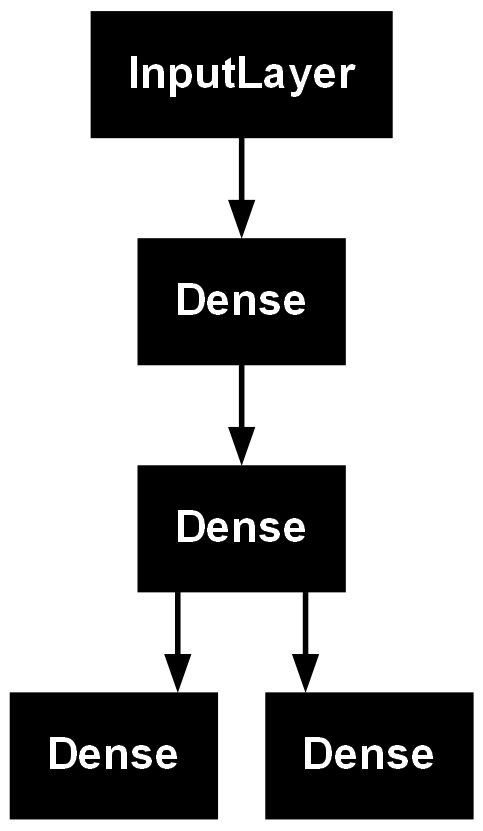

In [83]:
# 결과를 여러개로 나눠서 사용
input_ = keras.Input(shape=(10, 10), name='input_')
hidden1 = layers.Dense(100, activation='relu')(input_)
hidden2 = layers.Dense(10, activation='relu')(hidden1)
output = layers.Dense(1, activation='sigmoid', name='main_output')(hidden2)
sub_out = layers.Dense(1, name='sum_output')(hidden2)

model = models.Model(inputs=[input_], outputs=[output, sub_out])
model.summary()

utils.plot_model(model)

Model: "functional_44"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_2             │ (None, 10, 28)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_66 (Dense)    │ (None, 10, 100)   │      2,900 │ input_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_1             │ (None, 10, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_67 (Dense)    │ (None, 10, 10)    │      1,010 │ dense_66[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_8       │ (None, 10, 20)    │          0 │ input_1[0][0],    │
│ (Concatenate)       │                   │            │ dense_67[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ main_output (Dense) │ (None, 10, 1)     │         21 │ concatenate_8[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sum_output (Dense)  │ (None, 10, 1)     │         11 │ dense_67[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,942 (15.40 KB)

 Trainable params: 3,942 (15.40 KB)

 Non-trainable params: 0 (0.00 B)

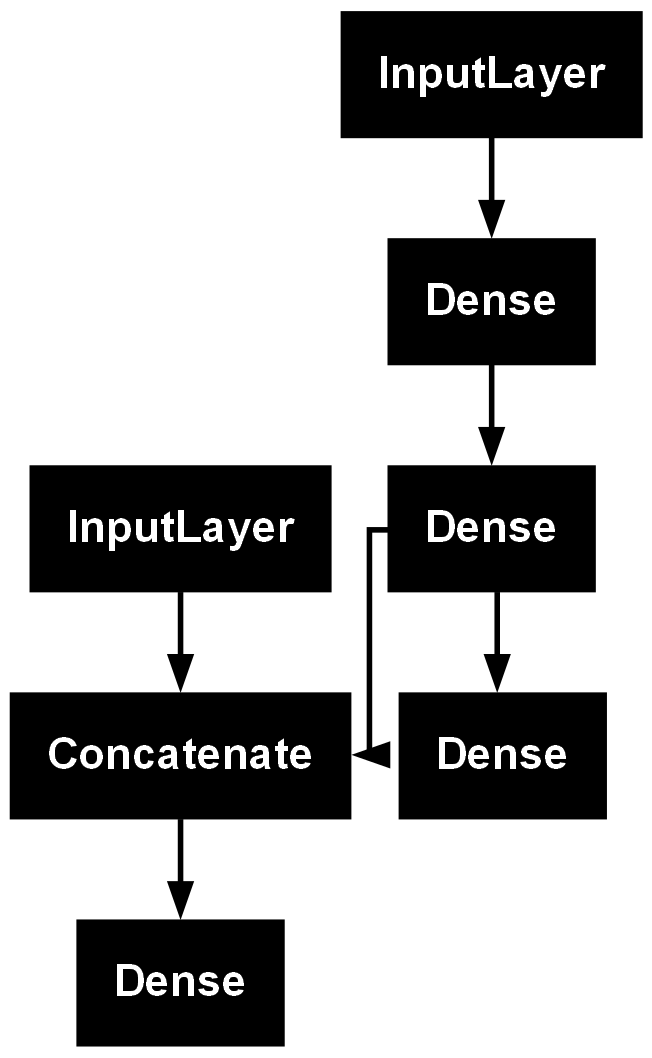

In [84]:
# 다중입력 다중출력
input_1 = keras.Input(shape=(10, 10), name='input_1')
input_2 = keras.Input(shape=(10, 28), name='input_2')
hidden1 = layers.Dense(100, activation='relu')(input_2)
hidden2 = layers.Dense(10, activation='relu')(hidden1)
concat = layers.Concatenate()([input_1, hidden2])
output = layers.Dense(1, activation='sigmoid', name='main_output')(concat)
sub_out = layers.Dense(1, name='sum_output')(hidden2)

model = models.Model(inputs=[input_1, input_2], outputs=[output, sub_out])
model.summary()

utils.plot_model(model)

### **Subclassing API**

- 클래싱(Subclassing) 방법은 커스터마이징에 최적화된 방법으로, 
- `Model` 클래스를 상속받아서 사용하고 모델에 포함되는 다음과 같은 기능을 사용할 수 있습니다.

    - `fit()`: 모델 학습
    - `evaluate()`: 모델 평가
    - `predict()`: 모델 예측
    - `save()`: 모델 저장
    - `load()`: 모델 불러오기
    - `call()`: 메소드안에서 원하는 계산 가능

Subclassing API를 사용하면 Functional API로도 구현할 수 없는 모델들도 구현이 가능하지만, 객체지향 프로그래밍(Object-oriented Programming)에 익숙해야 합니다.

d:\git\01_mdls_ds8_open\08_dl\260306_df_practice\.venv\Lib\site-packages\keras\src\layers\layer.py:424: UserWarning: `build()` was called on layer 'my_model_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model: "my_model_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_68 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_69 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_70 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_71 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

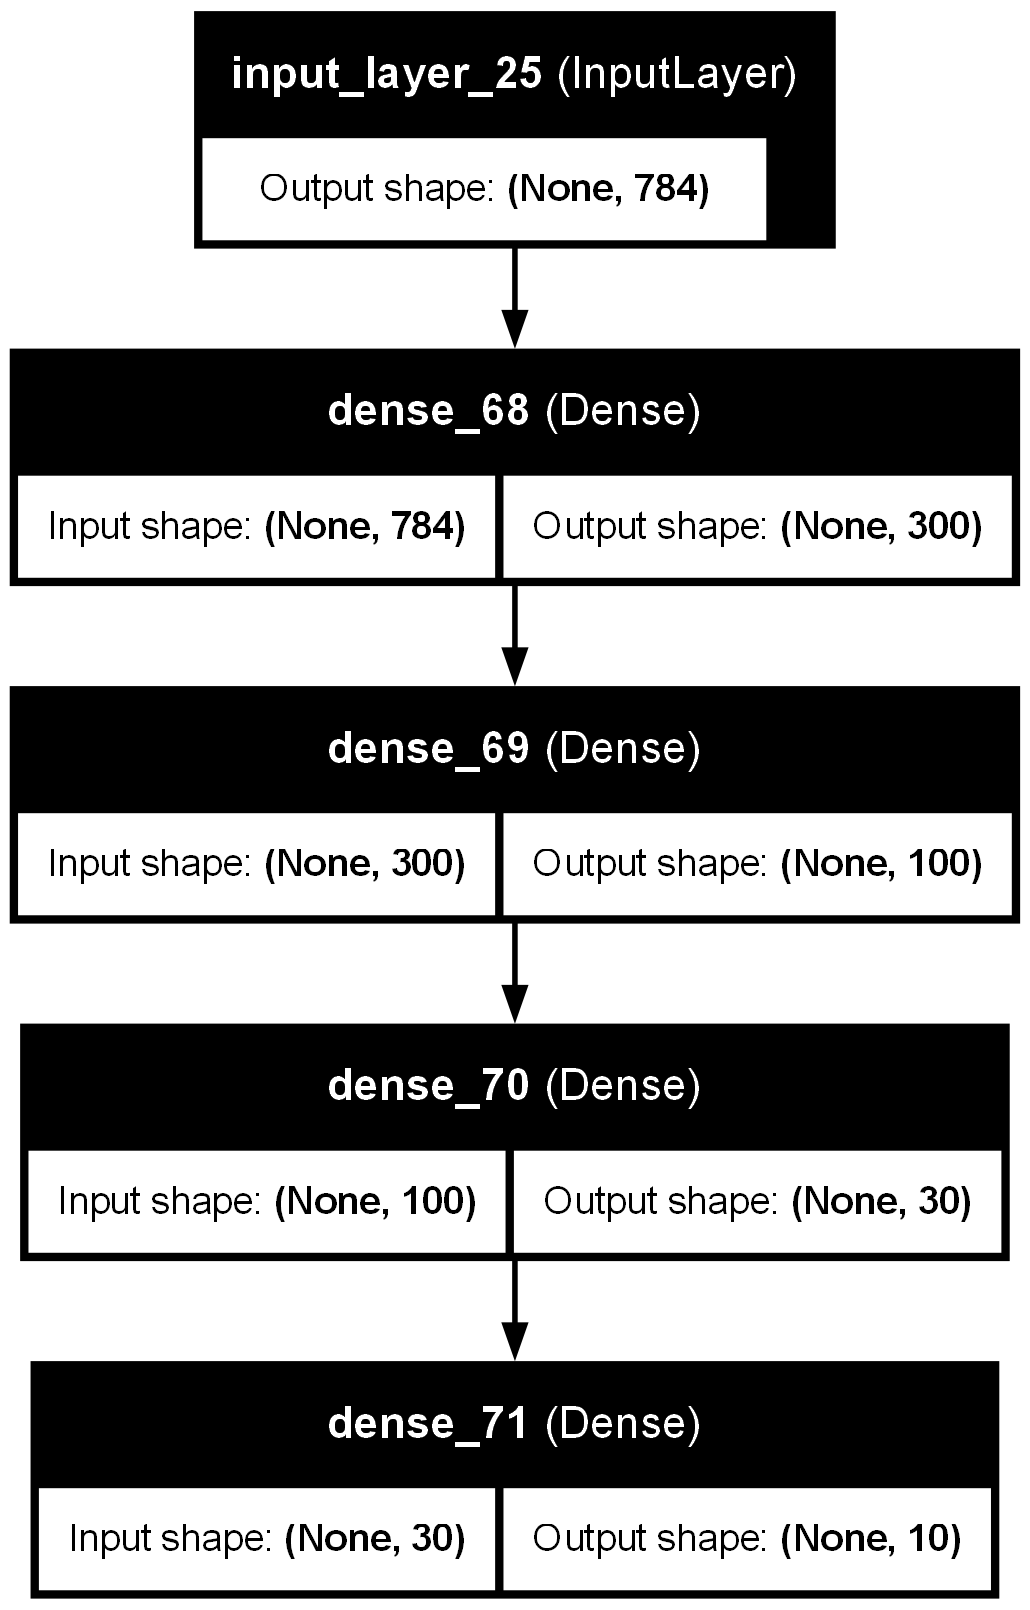

In [85]:
# Subclassing API의 예시
from tensorflow.keras import Model, layers, utils, Input

class MyModel(Model):
    def __init__(self, units=30, activation='relu', **kwargs):
        super(MyModel, self).__init__(**kwargs)
        self.dense_layer1 = layers.Dense(300, activation=activation)
        self.dense_layer2 = layers.Dense(100, activation=activation)
        self.dense_layer3 = layers.Dense(units, activation=activation)
        self.output_layer = layers.Dense(10, activation='softmax')

    def call(self, inputs):
        x = self.dense_layer1(inputs)
        x = self.dense_layer2(x)
        x = self.dense_layer3(x)
        x = self.output_layer(x)
        return x

    # summary, plot_model을 위한 helper (선택)
    def build_graph(self, input_shape):
        x = Input(shape=input_shape)
        return Model(inputs=x, outputs=self.call(x))

# 1) 인스턴스 생성
model = MyModel()

# 2) 빌드: 방법 A - build()로 shape 명시
model.build((None, 784))  # 예: 입력이 (batch, 784)인 경우
model.summary()

# 또는 방법 B - 더미 입력을 한 번 통과
# import tensorflow as tf
# _ = model(tf.random.normal((1, 784)))
# model.summary()

# 3) plot_model: build_graph()로 Functional 모델을 만들어 전달
func_model = model.build_graph((784,))  # batch 제외 shape
utils.plot_model(func_model,
                 to_file="model.png",
                 show_shapes=True,
                 show_layer_names=True)

##

## 종합퀴즈

- 모델을 한 번 구현해봅시다.
- 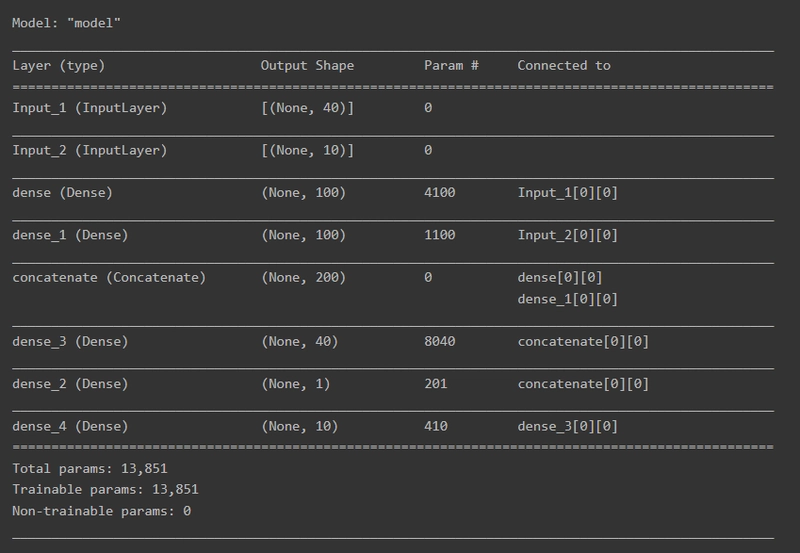
- 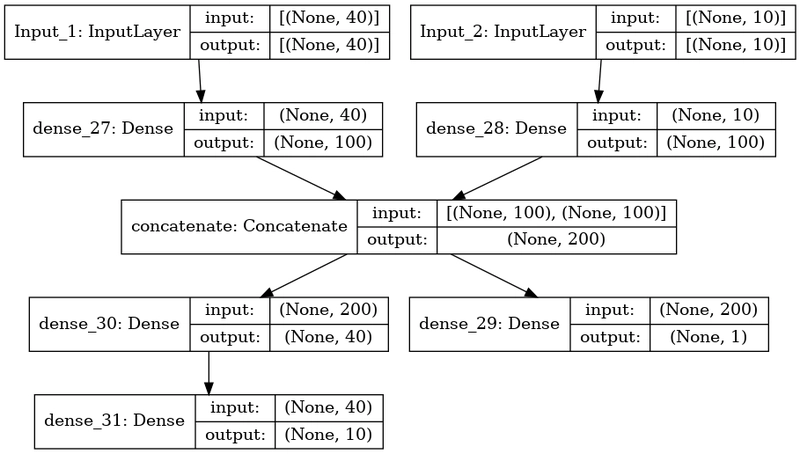

In [86]:
# 길이 40/10짜리 1차원 벡터를 받는 입력 텐서 정의
input1 = layers.Input(shape=(40,), name="Input_1")
input2 = layers.Input(shape=(10,), name="Input_2")

# 첫 번째 입력에 대해 Dense 레이어 적용
# - 유닛 100개: 특징을 100차원 표현으로 매핑
# - activation='relu': 비선형 변환으로 표현력 증가
# - name="dense": summary에서 보이는 레이어 이름과 맞추기 위함
x1 = layers.Dense(100, activation="relu", name="dense")(input1)

# 두 번째 입력에 대해 동일한 구조의 Dense 레이어 적용
# - 입력은 input2, 출력은 역시 (None, 100)
# - name="dense_1": summary에서 두 번째 Dense 레이어 이름
x2 = layers.Dense(100, activation="relu", name="dense_1")(input2)

# 두 Dense 레이어 출력(x1, x2)을 feature 차원(axis=-1) 기준으로 이어 붙이기
concat = layers.Concatenate(name="concatenate")([x1, x2])

# concat된 특징 벡터에서 바로 첫 번째 출력(out1)을 만드는 가지(branch)
out1 = layers.Dense(1, activation="linear", name="dense_2")(concat)

# 같은 concat 결과에서 두 번째 가지(branch)를 타게 하는 중간 레이어
h = layers.Dense(40, activation="relu", name="dense_3")(concat)

# 두 번째 가지의 최종 출력(out2)
out2 = layers.Dense(10, activation="linear", name="dense_4")(h)

# 다중 입력, 다중 출력 모델 정의
# - inputs: [input1, input2] → 두 개의 서로 다른 입력을 동시에 받는 구조
# - outputs: [out1, out2] → 첫 번째는 (None, 1), 두 번째는 (None, 10)
model = models.Model(
    inputs=[input1, input2],
    outputs=[out1, out2]
)

# 전체 구조, 각 레이어의 출력 shape, 파라미터 수를 표 형태로 확인
model.summary()


Model: "functional_46"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input_1             │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Input_2             │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 100)       │      4,100 │ Input_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 100)       │      1,100 │ Input_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 200)       │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 40)        │      8,040 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │        201 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 10)        │        410 │ dense_3[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 13,851 (54.11 KB)

 Trainable params: 13,851 (54.11 KB)

 Non-trainable params: 0 (0.00 B)

# 260306/dl/06_딥러닝 모델 학습

### 데이터 생성
- **선형회귀(Linear Regression)를 위한 딥러닝 모델** 을 만들어보도록 하겠습니다.
- **`make_regression`** 함수를 이용, 
    - 입력 X와 정답 y로 샘플 갯수(**`n_samples`**) 200개, 
    - 특징 갯수(**`n_featrues`**) 1개 
    - 바이어스(**`bias`**)는 5.0, 
    - 노이즈(**`noise`**)는 5.0,
    -  **`random_state`**는 123
- 데이터는 학습용 데이터셋(`x_train`, `y_train`), 테스트용 데이터셋(`x_test`, `y_test`)으로 구분합니다.

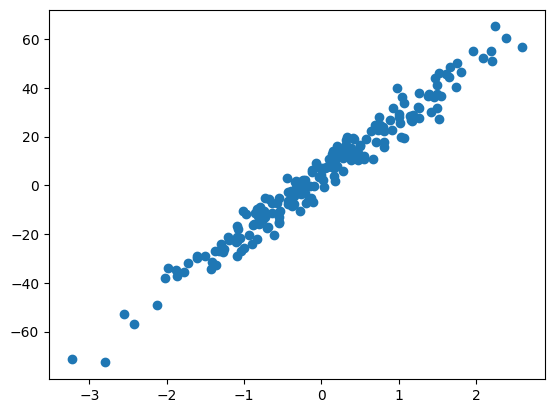

(160, 1) (160, 1)
(40, 1) (40, 1)


In [87]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

X, y = make_regression(n_samples=200, n_features=1, 
                       bias=5.0, noise=5.0, random_state=123)
y = np.expand_dims(y, axis=1)

plt.scatter(X, y)
plt.show()

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    shuffle=True,
                                                    random_state=123)

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

### 모델 생성
-  `Tensorflow`와 `keras`를 임포트
- `models`, `layers`, `optimizer`, `utils`도 임포트
    - 케라스(Keras)의 모델, 레이어, 옵티마이저, 유틸을 사용할 수 있도록 

- 모델은 간단하게 `Sequential()`을 이용해 선언하고, `Dense` 레이어 하나를 추가
    -  레이어의 유닛수는 1개
    - `activation`은 선형 회귀이니 'linear'로 지정
    - `input_shape`은 (1,) 으로 1차원 모양으로 입력 모양
    - 최종 모델의 구조를 `summary()` 함수를 통해 확인-


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_72 (Dense)                │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

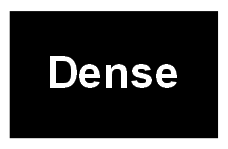

In [88]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import models, layers, optimizers, utils

model = keras.Sequential()
model.add(layers.Dense(1, activation='linear', input_shape=(1,)))
model.summary()

utils.plot_model(model)

### 모델 학습
- 옵티마이저(optimizer)로 **SGD(Stochastic Gradient Descent)** 를 사용
- **`compile()`** 함수를 통해서 손실 함수(loss function), 옵티마이저(optimizer), 지표(metrics)를 지정

Epoch 1/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 552.9482 - mae: 18.9568 - mse: 552.9482  
Epoch 2/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 443.8481 - mae: 16.9160 - mse: 443.8481 
Epoch 3/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 357.5332 - mae: 15.1878 - mse: 357.5332 
Epoch 4/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 289.3695 - mae: 13.7000 - mse: 289.3695 
Epoch 5/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 234.6745 - mae: 12.3079 - mse: 234.6745 
Epoch 6/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 191.3350 - mae: 11.0913 - mse: 191.3350 
Epoch 7/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 156.5821 - mae: 10.0318 - mse: 156.5821 
Epoch 8/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 128.9619 - mae: 9.0860 - mse: 128.9619  
Epoch 9/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 106.9301 - mae: 8.2814 - mse: 106.9301 
Epoch 10/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 89.4700 - mae: 7.5969 - mse: 89.4700 
Epoch 11/40
5/5 ━━━━━━━━━━━━━━━━

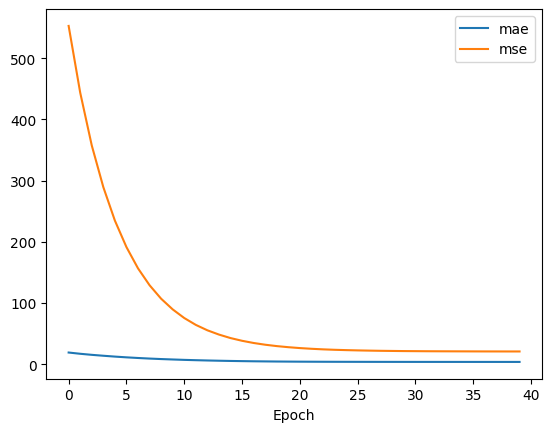

In [89]:
optimizer = optimizers.SGD()
model.compile(loss='mse', optimizer=optimizer, metrics=['mae', 'mse'])
history = model.fit(x_train, y_train, epochs=40)

plt.plot(history.history['mae'])
plt.plot(history.history['mse'])
plt.xlabel('Epoch')
plt.legend(['mae', 'mse'])
plt.show();

### 모델 평가/예측

In [90]:
#  evaluate() 함수를 이용하여 데이터셋인 x_test, y_test에 대해서 지표인 mae와 mse를 확인
model.evaluate(x_test, y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 21.9039 - mae: 3.9871 - mse: 21.9039


[21.903865814208984, 3.9871153831481934, 21.903865814208984]

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


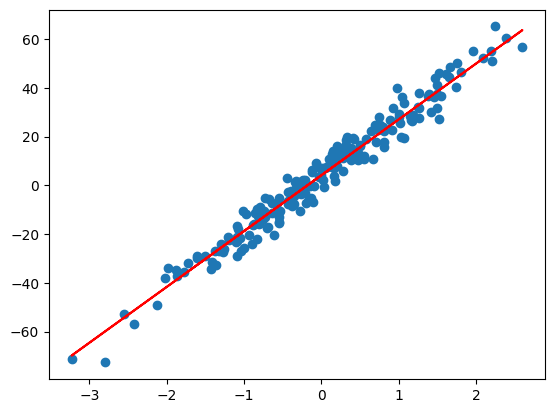

dense_72
dense_72
[[22.913103]]
[4.177394]


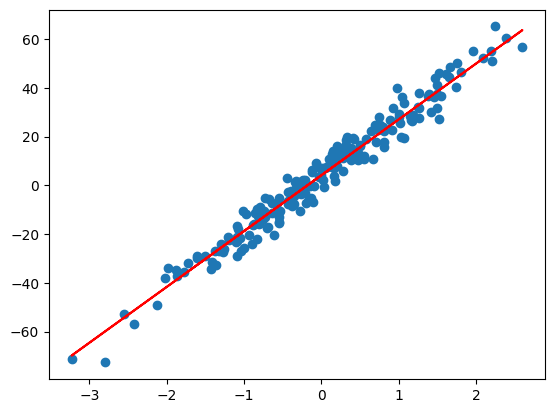

In [93]:
# 학습된 모델을 통해 입력 데이터 X 에 대한 예측값을 predict()를 통해 결과로 받아옵니다. 
# 실제 데이터의 결과값 y 와 모델의 예측 결과인 result를 살펴봅니다.

result = model.predict(X)

plt.scatter(X, y)
plt.plot(X, result, 'r')
plt.show()


# 딥러닝 모델에서 사용한 레이어를 layers로 접근하여 살펴볼 수 있습니다. 
# 여기에서는 Dense 레이어 하나만 사용된 것을 알 수 있습니다.
model.layers


# 모델의 0번째 레이어인 layers[0]를 가져와서 layer.name으로 
# 레이어의 이름을 확인할 수 있습니다. 
# 또한, get_layer() 함수를 통해 같은 이름의 레이어를 얻을 수도 있습니다.
layer = model.layers[0]
print(layer.name)
layer = model.get_layer('dense_72')
print(layer.name)


# 레이어에서 사용하는 가중치(weights)와 바이어스(biases)는
# get_weights() 함수를 통해서 얻을 수 있습니다. 
# 즉, 레이어에 있는 가중치와 바이어스를 통해 선형 회귀식을 얻을 수 있습니다.
weights, biases = layer.get_weights()
print(weights)
print(biases)

# 딥러닝 모델에서 학습된 가중치(weights)와 바이어스(biases)를 통해 
# 선형회귀식을 np.array(weights * X + biases)로 표현할 수 있습니다.
plt.scatter(X, y)
plt.plot(X, np.array(weights * X + biases), 'r')
plt.show()